# EquityAgent: Agent run and evaluation

GitHub repository: https://github.com/nicole-rowley-msaai/MS_AAI_520_NLP_GenAI_Final

This notebook runs the full agent on one ticker and prints every step, then
evaluates it against a single-prompt baseline and with memory on vs off.

## Agent Design and Workflows

The agent is a LangGraph state graph (`src/graph.py`):

```
ticker -> plan -> route -> specialists -> synthesize -> evaluate --pass--> reflect -> memory
                                                            |                 ^
                                                            +--refine--> optimize
```

| Requirement | Where | Printed below |
|---|---|---|
| Plans research steps | `agents/planner.py` | Section 2 |
| Uses tools dynamically | `agents/toolkit.py`, `tools/` | Section 3 |
| Routing | `agents/router.py` | Section 4 |
| Prompt chaining | `chains/news_chain.py` | Section 5 |
| Evaluator-optimizer | `agents/evaluator.py` | Section 7 |
| Self-reflection | `agents/evaluator.py: reflect` | Section 9 |
| Learns across runs | `memory/store.py` | Section 10 |

## 1. Setup

In [2]:
# Colab setup
import os
import sys

from google.colab import drive, userdata

REPO_URL = (
    f"https://{userdata.get('GITHUB_TOKEN')}@github.com/"
    "nicole-rowley-msaai/MS_AAI_520_NLP_GenAI_Final.git"
)
REPO = "/content/drive/MyDrive/equity-agent"

drive.mount("/content/drive")
if os.path.isdir(os.path.join(REPO, ".git")):
    %cd {REPO}
    !git pull -q
else:
    %cd /content/drive/MyDrive
    !git clone -q {REPO_URL} equity-agent
    %cd {REPO}
sys.path.insert(0, REPO)

SKIP = "google-adk\\|dependency resolver"
!pip install -q -r requirements.txt 2>&1 | grep -v "{SKIP}"

SECRET_KEYS = [
    "OPENAI_API_KEY",
    "ANTHROPIC_API_KEY",
    "FRED_API_KEY",
    "NEWSAPI_KEY",
    "EDGAR_USER_AGENT",
]
loaded = []
for key in SECRET_KEYS:
    try:
        os.environ[key] = userdata.get(key)
        loaded.append(key)
    except Exception:
        print(f"Missing secret: {key}")
print("Loaded:", loaded)

!git config --global user.name "nicole-rowley-msaai"
!git config --global user.email "nicolerowley@sandiego.edu"

Mounted at /content/drive
/content/drive/MyDrive/equity-agent
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 105.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.3/206.3 kB 21.4 MB/s 

In [3]:
import logging

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from src import display as show
from src.config import TICKERS
from src.evaluation import (
    baseline_brief, quick_smoke, score_against_findings,
    tool_success_rate, unsupported_figures,
)
from src.graph import run_agent
from src.memory import store
from src.tools.retrieval import index_filings

pd.set_option("display.max_colwidth", 120)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Agent Functions and Capabilities

### Setup check: every tool returns data, and the filing index is built

In [4]:
print("Chunks indexed:", index_filings(TICKERS))
pd.DataFrame({t: quick_smoke(t) for t in TICKERS})

Chunks indexed: 566


,NVDA,JPM,XOM
get_price_history,ok,ok,ok
get_key_stats,ok,ok,ok
get_financials,ok,ok,ok
get_macro_snapshot,ok,ok,ok
get_news,ok,ok,ok


## 2. Research plan

The planner reads memory first. On the first run of a ticker there are no
notes; later runs show the lessons it used.

In [5]:
TICKER = "NVDA"
notes_before = store.load_notes()

report, trace, state = run_agent(TICKER)

print("Sector:", state["sector"])
print("Hypothesis:", state["plan"].hypothesis)
show.plan_table(trace)

Sector: Technology
Hypothesis: Can Nvidia sustain its premium valuation given AI-driven demand growth against rising competition, customer concentration, and export restriction risks?


,id,task,tool,purpose,priority
0,1,"Gather current valuation multiples, margins, ROE, debt/equity, and beta for NVDA",get_key_stats,Establish baseline valuation and profitability metrics to assess if premium pricing is justified,high
1,2,"Review annual income statement, balance sheet, and cash flow trends over recent years",get_financials,"Assess revenue growth trajectory, margin expansion/compression, and balance sheet strength to support AI capex cycle",high
2,3,"Analyze 5-year price history for returns, volatility, and beta vs SPY",get_price_history,Understand historical risk/return profile and how the stock behaves in market drawdowns given high valuation,high
3,4,"Pull recent news on Nvidia covering product launches, customer deals, competition, and export controls",get_news,Capture latest catalysts and sentiment shifts that could impact near-term stock performance,high
4,5,"Search 10-K filings for risk factors related to customer concentration, export restrictions, and competitive threats",search_filings,"Identify material disclosed risks that could derail the growth narrative, especially China export rules and hypersca...",high
5,6,"Obtain latest macro snapshot including CPI, Fed funds rate, 10-year yield, and GDP trends",get_macro_snapshot,"Assess macro backdrop affecting high-multiple growth stocks, particularly interest rate sensitivity and capex spendi...",medium
6,7,Search filings for commentary on AI data center capex trends and supply chain constraints,search_filings,Understand management's view on sustainability of AI infrastructure spending and potential supply bottlenecks,medium


In [6]:
show.memory_read(trace)

,lesson


## 3. Tool calls (dynamic tool use)

In [7]:
show.tool_log(trace)

,tool,args,ok,rows,error
0,get_key_stats,{},True,13,None
1,get_financials,{},True,11,None
2,search_filings,"{'query': 'Search 10-K filings for risk factors related to customer concentration, export restrictions, and competit...",True,3,None
3,search_filings,{'query': 'Search filings for commentary on AI data center capex trends and supply chain constraints'},True,3,None
4,get_price_history,{},True,7,None
5,get_macro_snapshot,{},True,5,None
6,get_news,{},True,100,None


## 4. Routing decisions

In [8]:
show.routing_table(trace)

,step_id,route,reason
0,1,earnings,"Gathering NVDA’s valuation multiples, profitability margins, ROE, debt-to-equity, and beta requires financial-statis..."
1,2,earnings,"Reviewing multi-year income statements, balance sheets, and cash flows to assess revenue growth, margins, and financ..."
2,3,market,"Analyzing five-year returns, volatility, and beta versus SPY requires historical price-action and market-risk analysis."
3,4,news,"The task asks for recent Nvidia headlines on product launches, customer deals, competition, and export controls to a..."
4,5,earnings,"The task requires searching 10-K filing text for disclosed customer concentration, export restriction, and competiti..."
5,6,market,"The task requests current macro indicators and trends—CPI, policy rates, Treasury yields, and GDP—to assess interest..."
6,7,earnings,This task searches company filings for management commentary on AI data center capital spending sustainability and s...


## 5. News prompt chain: output of each step

In [9]:
show.news_chain_steps(trace)


=== INGEST ===
{
 "n": 100,
 "sample": [
  "NVIDIA App Ultimate Guide \u2014 Best Settings for Modern & Older Games, G-SYNC, DLSS, ShadowPlay, and More",
  "Nvidia and Micron stocks bounce on OpenAI $70B revenue target - Yahoo Finance",
  "livekit-plugins-nvidia 1.8.6",
  "Super Micro contractor pleads guilty in Nvidia AI chip rerouting scheme",
  "She Grew Up on Food Stamps and Started a Hedge Fund at MIT. Now Her 8-Figure Startup Counts Nvidia and OpenAI as Clients."
 ]
}

=== PREPROCESS ===
{
 "n_in": 100,
 "n_out": 86
}

=== CLASSIFY ===
{
 "0": {
  "id": 0,
  "topic": "product",
  "sentiment": "neutral",
  "relevance": "high"
 },
 "1": {
  "id": 1,
  "topic": "macro",
  "sentiment": "neutral",
  "relevance": "low"
 },
 "2": {
  "id": 2,
  "topic": "product",
  "sentiment": "neutral",
  "relevance": "high"
 },
 "3": {
  "id": 3,
  "topic": "legal",
  "sentiment": "negative",
  "relevance": "high"
 },
 "4": {
  "id": 4,
  "topic": "other",
  "sentiment": "neutral",
  "relevance": "

## 6. Specialist findings

In [10]:
show.findings_table(trace)

,route,summary,key_figures,risks
0,earnings,"Nvidia's FY2026 (ended Jan 31, 2026) revenue reached $215.94B, up 65.5% from $130.50B in FY2025, with operating inco...","[Revenue FY2026: $215.938B (FY2025: $130.497B), +65.5% YoY, Operating Income FY2026: $130.387B (60.4% margin) vs FY2...","[Customer concentration: ""A significant amount of our revenue stems from a limited number of partners and distributo..."
1,market,"NVDA closed at $229.28, up 5% over the past month and 21.24% over the past year, trading above both its 50-day SMA (...","[Last close: $229.28, 1-month return: 5%, 1-year return: 21.24%, Annualized volatility: 37.75%, SMA 50: $222.08, SMA...","[High beta (2.128) implies NVDA could see outsized declines if the broader market (SPY) sells off, Sharp rise in the..."
2,news,"Nvidia’s outlook and AI ecosystem activity remain supportive, but uncertainty around AI financing and customer reven...","[Management’s higher fiscal third-quarter sales outlook coincided with an 8.3% stock gain, supporting the near-term ...",[Firmus’s withdrawal of its planned $5 billion IPO amid weak demand and market volatility raises questions about AI ...


## Evaluation and Iteration

## 7. Evaluator-optimizer loop

Scores per iteration, the evaluator's critiques, and the score curve.

In [11]:
show.evaluation_history(state)

,iteration,average,completeness,evidence,accuracy,balance,clarity
0,0,3.6,4,3,4,4,3
1,1,4.2,5,4,4,5,3


In [12]:
show.critiques(state)


Iteration 0 (avg 3.6):
  - Distinguish the reported plans to invest in d-Matrix from a completed investment.
  - Do not treat reports about OpenAI revenue as evidence of Nvidia sales concentration; the findings do not establish that link.
  - Add the documented data-center power and capacity constraints and product-transition risks, which are material to the AI growth thesis.
  - Note that operating margin fell from 62.4% to 60.4% despite revenue growth.
  - Reconcile the stated 16.97% TTM debt/equity ratio with the separately cited $11.04B debt and $157.29B equity; those balance-sheet figures imply a different ratio.
  - Shorten repeated thesis and conclusion points so a portfolio manager can identify the stance and key decision factors within two minutes.

Iteration 1 (avg 4.2):
  - Replace the claim that the $169B market-cap change was a “swing” with the finding’s description: an approximately $169B loss in market value.
  - Remove the proposed explanation for the difference betwee

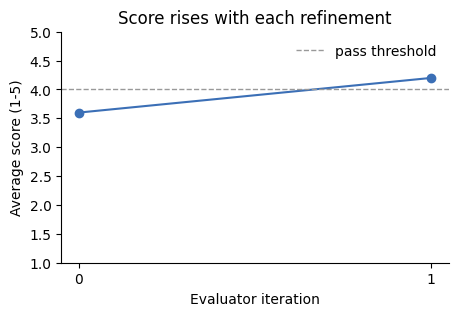

In [13]:
show.plot_scores(state)
plt.show()

## 8. Final report

In [14]:
display(Markdown(report))

# NVDA research brief

**Thesis:** Nvidia's FY2026 results are exceptional (revenue +65.5% to $215.94B, FCF $96.68B), cementing its AI infrastructure leadership, but operating margin compressed slightly (62.4%→60.4%) and the stock's premium valuation, 2.1-2.2x beta, and rising 10-year yields (5.22%) create a tighter risk/reward. Near-term AI demand signals are positive (raised Q3 guidance, ecosystem expansion), but export-policy volatility, data-center/power capacity constraints, and fragile AI-financing sentiment (Firmus IPO pulled, large insider sale, OpenAI-related selloff) are real execution and sentiment risks. Net: a high-quality compounder trading at a premium, best suited to disciplined, risk-aware sizing rather than unconditional conviction.

## Bull case
- FY2026 revenue grew 65.5% YoY to $215.94B with 60.4% operating margin and 55.6% net margin, reflecting exceptional scale economics
- Free cash flow rose to $96.68B (from $60.85B) with low total debt ($11.04B) against $157.29B equity, giving significant capital flexibility
- Forward P/E of 14.41x versus 28.99x trailing implies the market still sees room for continued earnings growth at a reasonable multiple
- Raised Q3 sales guidance drove an 8.3% stock gain, and Nvidia plus Micron are expected to contribute over one-third of S&P 500 Q3 EPS growth
- Ongoing AI ecosystem expansion—Nebius HGX B300 validation, a reported (not yet confirmed) potential investment in d-Matrix, and a $1B U.S. research pledge—reinforces Nvidia's central role in AI infrastructure buildout

## Bear case
- Filings disclose structural customer/channel concentration risk (reliance on a limited number of partners and distributors); this is a disclosed risk factor, not directly evidenced by the recent OpenAI-related stock move
- Export-control uncertainty remains a wildcard, highlighted by the $4.5B H20 inventory charge in Q1 FY2026 tied to China licensing; policy is still fluid even after partial license approvals
- Data-center power/energy availability and complex, multi-year product transitions are disclosed risks that could cause supply-demand mismatches, inventory provisions, or delayed revenue
- Market sentiment around AI capex looks fragile: a report of lower-than-expected OpenAI revenue triggered a ~$169B market-cap swing, Firmus withdrew its $5B IPO amid weak demand, and a director sold ~$947M in shares
- High beta (2.13-2.22x), 37.75% annualized volatility, and a sharply higher 10-year Treasury yield (5.22%, up from 4.13%) increase both market-driven downside risk and the discount rate applied to this richly valued growth stock

## Fundamentals
Nvidia's FY2026 revenue reached $215.94B (+65.5% YoY), with operating income of $130.39B; operating margin actually declined slightly to 60.4% from 62.4% in FY2025 despite the revenue surge, worth monitoring as a cost or mix signal. Net income was $120.07B (55.6% margin) and diluted EPS rose to $4.90 from $2.94. Operating cash flow reached $102.72B and free cash flow $96.68B (both up ~60% YoY), while capex roughly doubled to $6.04B as infrastructure scales. The balance sheet shows $157.29B in equity against $11.04B total debt—a ratio of roughly 7%, notably lower than the separately reported TTM debt/equity of 16.97%; this discrepancy likely reflects a broader TTM liability base (e.g., leases or other obligations) not fully specified in the available data and should be clarified before relying on either figure precisely. Valuation is elevated on trailing metrics (28.99x P/E, 24.18x P/B) but more moderate on a forward basis (14.41x P/E), with ROE of 117.2% and a negligible 0.43% dividend yield.

## News and catalysts
Positive catalysts include a raised fiscal Q3 sales outlook (driving an 8.3% stock gain) and Nvidia/Micron's expected contribution of over one-third of S&P 500 Q3 EPS growth, reflecting broad AI-driven earnings momentum. Nvidia continues ecosystem expansion via Nebius HGX B300 rack validation, a reported but unconfirmed potential investment in chip developer d-Matrix, and a $1B commitment to U.S. scientific research. Negative catalysts include Firmus's withdrawal of its $5B IPO amid weak demand (an AI-funding sentiment signal), a 2.94% share decline and ~$169B market-cap swing following reports of weaker-than-expected OpenAI revenue (a sentiment-driven reaction, not confirmed evidence of Nvidia-specific customer concentration), a ~$947M insider stock sale by a director, a high-severity GPU monitoring vulnerability, and a legal case involving a contractor rerouting Nvidia AI chips—together pointing to channel-control and operational risks alongside genuine disclosed risks around data-center power constraints and product-transition complexity.

## Market and macro
NVDA trades at $229.28, up 5% over the past month and 21.24% over the past year, holding above its 50-day ($222.08) and 200-day ($202.15) moving averages in a sustained uptrend. Annualized volatility of 37.75% and a beta of 2.13-2.22x versus the broad market mean the stock is prone to outsized swings in either direction. Macro conditions are mixed: the Fed has cut rates to 3.75% (from 4.22%) and unemployment has edged down to 4.2%, supporting growth, but the 10-year Treasury yield has risen sharply to 5.22% (from 4.13%), raising the discount rate on long-duration growth stocks, while CPI remains above target at 3.35% YoY, adding policy uncertainty.

## Conclusion
Fundamentals remain exceptional, but slight margin compression, a premium valuation, high beta/volatility, rising long-term yields, and disclosed execution risks (export policy, data-center capacity, product transitions) warrant a constructive-but-risk-aware stance rather than unconditional conviction. The long-term AI infrastructure thesis is intact; near-term price action is more sensitive to rates and AI-spending sentiment than to any confirmed customer-concentration event. Disciplined position sizing is appropriate. This is analysis, not investment advice.

*Analysis only; not investment advice.*

## 9. Reflection (self-assessment of output and process)

In [15]:
show.reflection_view(state)

{'weakest_section': 'Fundamentals/Market and macro valuation context',
 'unsupported_claims': ['Reported but unconfirmed potential investment in d-Matrix is stated in both bull case and news section as an ecosystem-expansion positive without clear caveats on probability or deal size',
  '"Nvidia and Micron are expected to contribute over one-third of S&P 500 Q3 EPS growth" is repeated as a hard data point but is a third-party projection, not verified against primary data',
  "The insider sale (~$947M) is framed as a 'potentially negative insider-trading signal' without checking if it was a scheduled 10b5-1 sale, which would materially change its interpretation",
  'The debt/equity discrepancy (7% vs 16.97% TTM) is flagged as a caveat but the brief still uses both figures in the narrative without resolving which is more reliable'],
 'missing_data': ['Segment-level revenue breakdown (data center vs gaming vs automotive vs professional visualization) to assess true customer/product concen

## 10. Memory: what this run taught the agent

New lessons written to `memory/notes.json`, then a second run on the same
ticker to show the planner reading them.

In [16]:
show.memory_diff(trace)

,ticker,sector,date,lesson
0,NVDA,Technology,2026-10-11,"For capital-intensive AI/semiconductor companies, pull segment-level revenue breakdowns to substantiate or refute cu..."
1,NVDA,Technology,2026-10-11,"When a stock move is attributed to 'raised guidance,' capture the actual guidance numbers (old vs new, consensus vs ..."
2,NVDA,Technology,2026-10-11,"Always reconcile conflicting leverage/valuation metrics (e.g., balance-sheet debt/equity vs TTM debt/equity) before ..."
3,NVDA,Technology,2026-10-11,"For high-beta growth stocks, pair volatility/beta stats with analyst consensus price targets and peer multiples so '..."
4,NVDA,Technology,2026-10-11,Treat insider sales as directional signals only after checking filing type (10b5-1 scheduled vs discretionary) — und...


In [17]:
report2, trace2, state2 = run_agent(TICKER)
print("Lessons the planner read on run 2:")
display(show.memory_read(trace2))
print("Run 1 steps:", [s.tool for s in state["plan"].steps])
print("Run 2 steps:", [s.tool for s in state2["plan"].steps])
print("Run 1 final score:", state["history"][-1]["average"],
      "| Run 2 final score:", state2["history"][-1]["average"])

Lessons the planner read on run 2:


,ticker,sector,date,lesson
0,NVDA,Technology,2026-10-11,"For capital-intensive AI/semiconductor companies, pull segment-level revenue breakdowns to substantiate or refute cu..."
1,NVDA,Technology,2026-10-11,"When a stock move is attributed to 'raised guidance,' capture the actual guidance numbers (old vs new, consensus vs ..."
2,NVDA,Technology,2026-10-11,"Always reconcile conflicting leverage/valuation metrics (e.g., balance-sheet debt/equity vs TTM debt/equity) before ..."
3,NVDA,Technology,2026-10-11,"For high-beta growth stocks, pair volatility/beta stats with analyst consensus price targets and peer multiples so '..."
4,NVDA,Technology,2026-10-11,Treat insider sales as directional signals only after checking filing type (10b5-1 scheduled vs discretionary) — und...


Run 1 steps: ['get_key_stats', 'get_financials', 'get_price_history', 'get_news', 'search_filings', 'get_macro_snapshot', 'search_filings']
Run 2 steps: ['get_key_stats', 'get_financials', 'get_price_history', 'get_news', 'search_filings', 'get_macro_snapshot', 'search_filings']
Run 1 final score: 4.2 | Run 2 final score: 4.2


## 11. Evaluation

Three comparisons, all scored with the same rubric and the same findings:

1. **Baseline vs agent:** a single prompt with no tools, no plan, no loop.
2. **Numeric spot-check:** figures in each brief that appear in no finding.
3. **Memory on vs off:** the same ticker with memory disabled.

In [ ]:
rows = []
for t in TICKERS:
    rep, tr, st = run_agent(t)
    base = baseline_brief(t)
    base_score = score_against_findings(base, st["findings"])
    findings = st["findings"]
    rows.append(
        {
            "ticker": t,
            "baseline_avg": base_score["average"],
            "agent_first_draft": st["history"][0]["average"],
            "agent_final": st["history"][-1]["average"],
            "iterations": len(st["history"]),
            "tool_success": tool_success_rate(tr),
            "unsupported_baseline": len(unsupported_figures(base, findings)),
            "unsupported_agent": len(
                unsupported_figures(st["draft"], findings)
            ),
        }
    )
results = pd.DataFrame(rows)
results

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3.2))
x = list(range(len(results)))
w = 0.27
series = [
    ("baseline_avg", "baseline", "#b5b5b5", -w),
    ("agent_first_draft", "agent, first draft", "#8fb3e0", 0),
    ("agent_final", "agent, final", "#3b6fb6", w),
]
for col, label, color, offset in series:
    ax.bar([i + offset for i in x], results[col], w, label=label, color=color)
ax.set_xticks(x, results["ticker"])
ax.set_ylim(1, 5)
ax.set_ylabel("Rubric average (1-5)")
ax.set_title("Agent beats the single-prompt baseline on every ticker")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8)
plt.show()

In [ ]:
_, tr_off, st_off = run_agent(TICKER, use_memory=False)
_, tr_on, st_on = run_agent(TICKER, use_memory=True)
pd.DataFrame([
    {"memory": "off", "plan_steps": len(st_off["plan"].steps),
     "notes_read": len(tr_off.select("memory", "read")[0].output),
     "final_score": st_off["history"][-1]["average"]},
    {"memory": "on", "plan_steps": len(st_on["plan"].steps),
     "notes_read": len(tr_on.select("memory", "read")[0].output),
     "final_score": st_on["history"][-1]["average"]},
])

In [ ]:
show.timing_table(trace)

## Limitations

- Figures come from free data sources (`yfinance` is unofficial; NewsAPI
  caps at 100 articles) and are cached, so a run reflects the cache date.
- The evaluator is an LLM and its scores vary by about 0.2 between runs.
- The agent has no view of future events, and the brief is analysis only,
  not investment advice.